# 01 — Exploratory Data Analysis

**Dataset:** Kaggle ULB Credit Card Fraud (September 2013, European cardholders)

| Property | Value |
|---|---|
| Transactions | 284,807 |
| Frauds | 492 (0.173%) |
| Features | V1–V28 (PCA-anonymized), `Time` (seconds from first txn), `Amount` |
| Target | `Class` (1 = fraud) |

Questions we answer here:
1. How extreme is the class imbalance?
2. Do fraud amounts differ from legitimate amounts?
3. Is there a time-of-day pattern in fraud?
4. Which features correlate most with fraud?

In [1]:
import sys
from pathlib import Path

# Make project root importable regardless of where the kernel starts
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src import config

sns.set_theme(style="whitegrid", palette="deep")
FIG = config.FIGURES
FIG.mkdir(parents=True, exist_ok=True)
print("Project root:", ROOT)

Project root: C:\Personal\IIT_HYD\Project


## 1. Load data

In [2]:
df = pd.read_csv(config.RAW_CSV)
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.dtypes.value_counts()

float64    30
int64       1
Name: count, dtype: int64

All numeric (28 PCA components + Time + Amount float64, Class int64).
No categorical encoding will be needed.

## 2. Class distribution

In [4]:
y = df[config.TARGET_COL]
counts = y.value_counts()
print(counts)
print(f"Imbalance ratio: {counts[0] / counts[1]:.1f} : 1")
print(f"Fraud percentage: {100 * counts[1] / len(df):.3f}%")

Class
0    284315
1       492
Name: count, dtype: int64
Imbalance ratio: 577.9 : 1
Fraud percentage: 0.173%


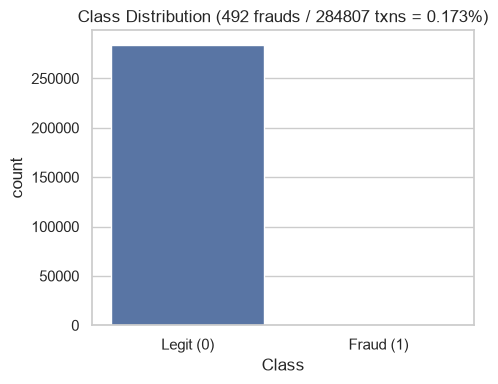

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=y.map({0: "Legit (0)", 1: "Fraud (1)"}), hue=y,
              palette=["#4c72b0", "#c44e52"], legend=False, ax=ax)
ax.set_title(f"Class Distribution ({counts[1]} frauds / {len(df)} txns = {100 * counts[1] / len(df):.3f}%)")
fig.tight_layout()
fig.savefig(FIG / "01_class_distribution.png", dpi=150)
plt.show()

**Takeaway:** ~578 : 1 imbalance. Accuracy is meaningless here — predicting "legit"
for everything gives 99.83% accuracy while catching zero fraud.

→ We will evaluate with **PR-AUC (average precision)**, F1, MCC, and recall at fixed FPR.

## 3. Missing values

In [6]:
n_missing = int(df.isna().sum().sum())
print(f"Total missing values: {n_missing}")

Total missing values: 0


Clean dataset — no imputation required.

## 4. Transaction amount vs class

In [7]:
df.groupby(config.TARGET_COL)["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


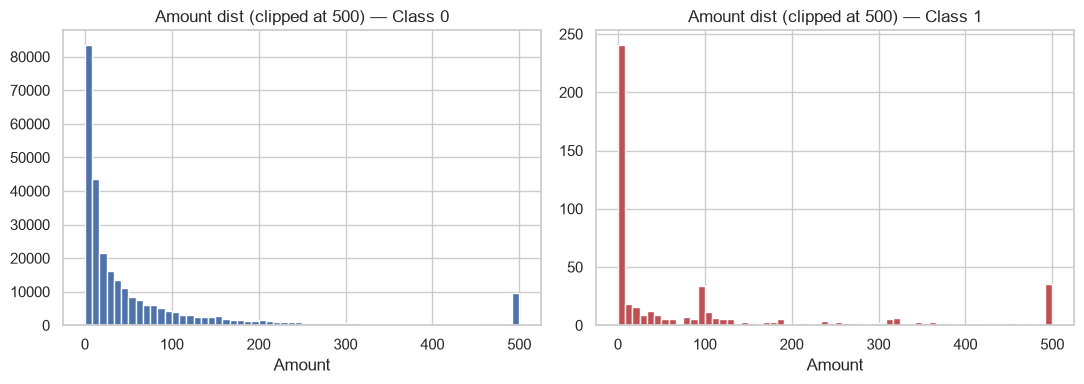

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for cls, ax in zip([0, 1], axes):
    amounts = df.loc[y == cls, "Amount"]
    ax.hist(amounts.clip(upper=500), bins=60, color=["#4c72b0", "#c44e52"][cls])
    ax.set_title(f"Amount dist (clipped at 500) — Class {cls}")
    ax.set_xlabel("Amount")
fig.tight_layout()
fig.savefig(FIG / "02_amount_by_class.png", dpi=150)
plt.show()

**Takeaway:** Fraud transactions skew toward **small amounts** (median \$9.25 vs \$22 for legit)
but have a higher mean (\$122 vs \$88) — a heavy tail of larger frauds. Max fraud amount is
\$2,126 vs \$25,691 for legit. `Amount` is heavily right-skewed → we'll add a log-transformed feature later.

## 5. Time-of-day pattern

In [9]:
df["hour"] = ((df["Time"] // 3600) % 24).astype(int)
fraud_by_hour = df.groupby("hour")[config.TARGET_COL].agg(["mean", "count"])
fraud_by_hour["mean"] *= 100
fraud_by_hour.round(3)

,mean,count
hour,,
0,0.078,7695
1,0.237,4220
2,1.713,3328
3,0.487,3492
4,1.041,2209
5,0.368,2990
6,0.219,4101
7,0.318,7243
8,0.088,10276


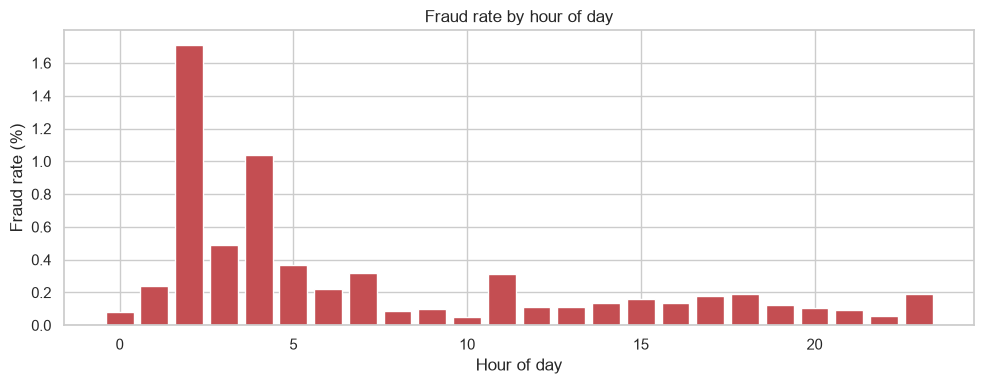

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(fraud_by_hour.index, fraud_by_hour["mean"], color="#c44e52")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Fraud rate (%)")
ax.set_title("Fraud rate by hour of day")
fig.tight_layout()
fig.savefig(FIG / "03_fraud_rate_by_hour.png", dpi=150)
plt.show()

**Takeaway:** Clear temporal signal — fraud rate spikes at **hours 2–4** (~1–1.7%, i.e. 6–10x
the average rate). Justifies (a) keeping `Time`-derived features and (b) a **time-based train/test split**
(train on early txns, test on late ones) which mimics real deployment.

## 6. Feature correlations with fraud

In [11]:
corr = df.drop(columns=["hour"]).corr()[config.TARGET_COL].drop(config.TARGET_COL)
corr.abs().sort_values(ascending=False).head(10).round(4).to_frame("|corr|")

,|corr|
V17,0.3265
V14,0.3025
V12,0.2606
V10,0.2169
V16,0.1965
V3,0.1930
V7,0.1873
V11,0.1549
V4,0.1334
V18,0.1115


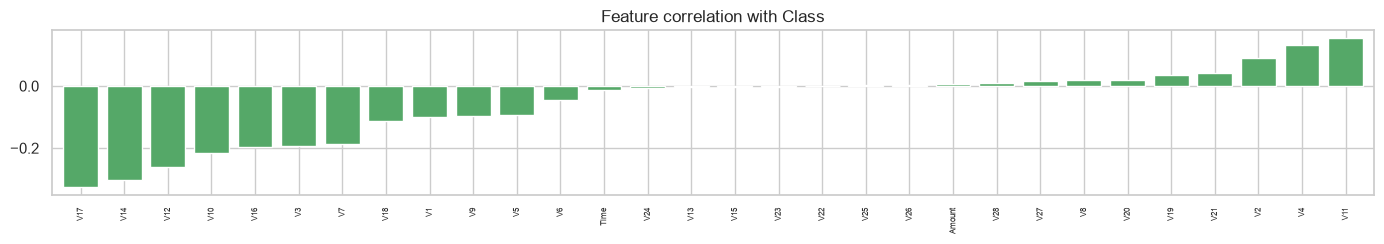

In [12]:
fig, ax = plt.subplots(figsize=(14, 2.6))
corr.sort_values().plot.bar(ax=ax, color="#55a868", width=0.8)
ax.set_title("Feature correlation with Class")
ax.tick_params(axis="x", labelsize=6)
fig.tight_layout()
fig.savefig(FIG / "04_feature_correlations.png", dpi=150)
plt.show()

**Takeaway:** Strongest signals are negative correlations — **V17 (-0.33), V14 (-0.30),
V12 (-0.26), V10 (-0.22)**, plus positive V11 (+0.15). No single feature separates classes
fully → non-linear models (boosting/NN/GNN) have room to add value over linear ones.

## 7. EDA conclusions → modeling decisions

| Finding | Decision |
|---|---|
| 577:1 imbalance | PR-AUC primary metric; compare sampling strategies (class weights, SMOTE, hybrid) |
| No missing values | Skip imputation |
| Skewed Amount | Add `log_Amount` feature; tree models get raw Amount too |
| Hourly fraud spike | Derive hour-of-day features from Time |
| Temporal structure | Time-based 70/15/15 split, test set stays imbalanced |
| Moderate single-feature correlations | Baseline LR → then RF/XGBoost/LightGBM/CatBoost → MLP/AE/LSTM → GNN |